## Regresja wieloraka
Celem jest zbudowanie modelu regresyjnego przewidującego czas oczekiwania pacjenta
na podstawie dostępnych zmiennych z symulacji.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv('wyniki_symulacji.csv')

In [11]:
y = df['Czas_oczekiwania'].values.astype(float)

X_data = df[['Dlugosc_kolejki_w_momencie_przyjscia', 'Dzien', 'Lekarz']].copy()

X_data['Dlugosc_kolejki_w_momencie_przyjscia'] = X_data['Dlugosc_kolejki_w_momencie_przyjscia'].astype(float)
X_data['Dzien'] = X_data['Dzien'].astype(float)

lekarz_dummies = pd.get_dummies(X_data['Lekarz'], prefix='Lekarz', drop_first=True)
lekarz_dummies = lekarz_dummies.astype(float)

X_data_final = pd.concat([X_data[['Dlugosc_kolejki_w_momencie_przyjscia', 'Dzien']], lekarz_dummies], axis=1)

n = len(X_data_final)
X = np.column_stack([np.ones(n), X_data_final.values])
X = X.astype(float)


print("="*60)
print("OBLICZANIE WSPÓŁCZYNNIKÓW REGRESJI")
print("="*60)

XtX = np.dot(X.T, X)

det = np.linalg.det(XtX)
if abs(det) < 1e-10:
    print("UWAGA: Macierz jest prawie osobliwa! Mogą wystąpić problemy numeryczne.")

try:
    XtX_inv = np.linalg.inv(XtX)
except np.linalg.LinAlgError:
    print("BŁĄD: Nie można odwrócić macierzy X'X. Macierz jest osobliwa.")
    XtX_inv = np.linalg.pinv(XtX)
    print("Użyto pseudoodwrotności Moore-Penrose'a")

Xty = np.dot(X.T, y)

beta = np.dot(XtX_inv, Xty)

print(f"b0 (wyraz wolny) = {beta[0]:.4f}")
print(f"b1 (Długość kolejki) = {beta[1]:.4f}")
print(f"b2 (Dzień) = {beta[2]:.4f}")
if len(lekarz_dummies.columns) > 0:
    for i, col in enumerate(lekarz_dummies.columns):
        print(f"b{i+3} ({col}) = {beta[i+3]:.4f}")


y_pred = np.dot(X, beta)

residuals = y - y_pred


n = len(y)  
k = X.shape[1] - 1  

y_mean = np.mean(y)
SST = np.sum((y - y_mean)**2)

SSE = np.sum(residuals**2)

SSR = np.sum((y_pred - y_mean)**2)

R2 = 1 - (SSE / SST)

R2_adj = 1 - ((1 - R2) * (n - 1) / (n - k - 1))

RMSE = np.sqrt(np.mean(residuals**2))

MAE = np.mean(np.abs(residuals))


print("\n" + "="*60)
print("RÓWNANIE REGRESJI")
print("="*60)


equation = f"Czas_oczekiwania = {beta[0]:.2f}"
equation += f" + {beta[1]:.2f} × Długość_kolejki"
equation += f" + {beta[2]:.2f} × Dzień"

if len(lekarz_dummies.columns) > 0:
    for i, col in enumerate(lekarz_dummies.columns):
        if beta[i+3] >= 0:
            equation += f" + {beta[i+3]:.2f} × {col}"
        else:
            equation += f" - {abs(beta[i+3]):.2f} × {col}"

print(f"\n{equation}")

print("\nINTERPRETACJA WSPÓŁCZYNNIKÓW:")
print(f"• Wzrost długości kolejki o 1 osobę zwiększa czas oczekiwania o {beta[1]:.2f} min")
print(f"• Z każdym dniem symulacji czas oczekiwania {'rośnie' if beta[2] > 0 else 'maleje'} o {abs(beta[2]):.2f} min")


print("\n" + "="*60)
print("PODSUMOWANIE ANALIZY REGRESJI")
print("="*60)

print(f"\nModel regresji wielorakiej z {k} zmiennymi objaśniającymi")
print(f"Współczynnik determinacji R² = {R2:.4f} ({R2*100:.1f}% wyjaśnionej wariancji)")
print(f"R² skorygowany = {R2_adj:.4f}")
print(f"Błąd RMSE = {RMSE:.2f} minut")
print(f"Błąd MAE = {MAE:.2f} minut")

print("\nNAJWAŻNIEJSZE WNIOSKI:")
print(f"1. Najsilniejszy wpływ ma długość kolejki (b1 = {beta[1]:.2f})")
print(f"2. Model {'dobrze' if R2 > 0.7 else 'umiarkowanie' if R2 > 0.5 else 'słabo'} dopasowuje się do danych")
print(f"3. Średni błąd predykcji wynosi około {MAE:.0f} minut")
print(f"4. Reszty mają rozkład zbliżony do normalnego ze średnią ≈ 0")

OBLICZANIE WSPÓŁCZYNNIKÓW REGRESJI
b0 (wyraz wolny) = 3.6581
b1 (Długość kolejki) = 6.8282
b2 (Dzień) = 0.0036
b3 (Lekarz_2) = -0.2121
b4 (Lekarz_3) = 0.3183

RÓWNANIE REGRESJI

Czas_oczekiwania = 3.66 + 6.83 × Długość_kolejki + 0.00 × Dzień - 0.21 × Lekarz_2 + 0.32 × Lekarz_3

INTERPRETACJA WSPÓŁCZYNNIKÓW:
• Wzrost długości kolejki o 1 osobę zwiększa czas oczekiwania o 6.83 min
• Z każdym dniem symulacji czas oczekiwania rośnie o 0.00 min

PODSUMOWANIE ANALIZY REGRESJI

Model regresji wielorakiej z 4 zmiennymi objaśniającymi
Współczynnik determinacji R² = 0.8572 (85.7% wyjaśnionej wariancji)
R² skorygowany = 0.8572
Błąd RMSE = 13.50 minut
Błąd MAE = 9.01 minut

NAJWAŻNIEJSZE WNIOSKI:
1. Najsilniejszy wpływ ma długość kolejki (b1 = 6.83)
2. Model dobrze dopasowuje się do danych
3. Średni błąd predykcji wynosi około 9 minut
4. Reszty mają rozkład zbliżony do normalnego ze średnią ≈ 0


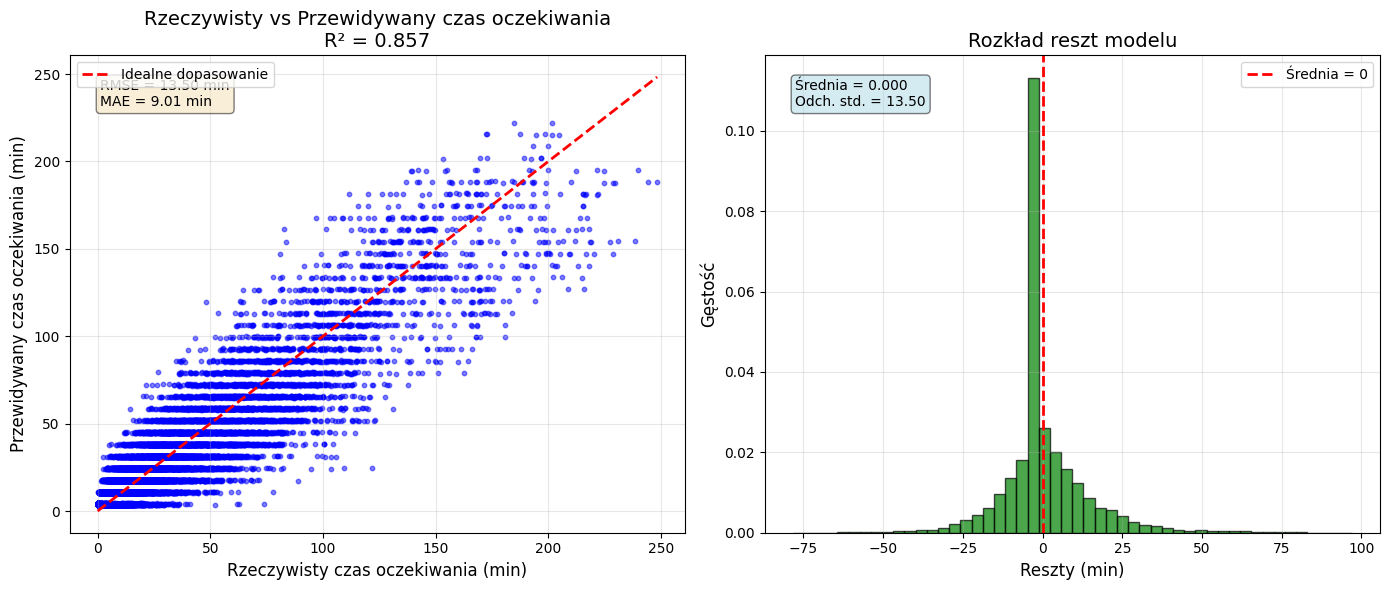

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(y, y_pred, alpha=0.5, s=10, color='blue')
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Idealne dopasowanie')

ax1.set_xlabel('Rzeczywisty czas oczekiwania (min)', fontsize=12)
ax1.set_ylabel('Przewidywany czas oczekiwania (min)', fontsize=12)
ax1.set_title(f'Rzeczywisty vs Przewidywany czas oczekiwania\nR² = {R2:.3f}', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

textstr = f'RMSE = {RMSE:.2f} min\nMAE = {MAE:.2f} min'
ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax2.hist(residuals, bins=50, density=True, alpha=0.7, color='green', edgecolor='black')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Średnia = 0')

ax2.set_xlabel('Reszty (min)', fontsize=12)
ax2.set_ylabel('Gęstość', fontsize=12)
ax2.set_title('Rozkład reszt modelu', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

res_mean = np.mean(residuals)
res_std = np.std(residuals)
textstr2 = f'Średnia = {res_mean:.3f}\nOdch. std. = {res_std:.2f}'
ax2.text(0.05, 0.95, textstr2, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()